In [2]:
import fastf1
import pandas as pd
import os

os.makedirs('f1_cache1', exist_ok=True)
fastf1.Cache.enable_cache('f1_cache1')

In [4]:
races = [
    (2023, 'Australia'),
    (2023, 'Bahrain'),
    (2023, 'Monaco'),
    (2023, 'Britain'),
    (2023, 'Italy'),
    (2023, 'Singapore')
]

all_laps_list = []

for i, j in races:
    session = fastf1.get_session(i, j, 'R')
    session.load()
    laps = session.laps.copy()
    laps['Race'] = j  # adds the race name as a column
    all_laps_list.append(laps)

all_laps_df = pd.concat(all_laps_list, ignore_index=True)
print(all_laps_df.shape)
print(all_laps_df['Race'].unique())

    

Request for URL https://raw.githubusercontent.com/theOehrly/f1schedule/master/schedule_2023.json failed; using cached response
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
        conn,
    ...<10 lines>...
        **response_kw,
    )
  File "/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "/opt/anaconda3/lib/python3.13/site-packages/urllib3/connection.py", line 516, in getresponse
    httplib_response = super().getresponse()
  File "/opt/anaconda3/lib/python3.13/http/client.py", line 1430, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/http/client.py",

(6591, 32)
['Australia' 'Bahrain' 'Monaco' 'Britain' 'Italy' 'Singapore']


In [5]:
clean_laps = all_laps_df[all_laps_df['IsAccurate'] == True].copy()
clean_laps['LapTimeSeconds'] = clean_laps['LapTime'].dt.total_seconds()
print(clean_laps.shape)

(5744, 33)


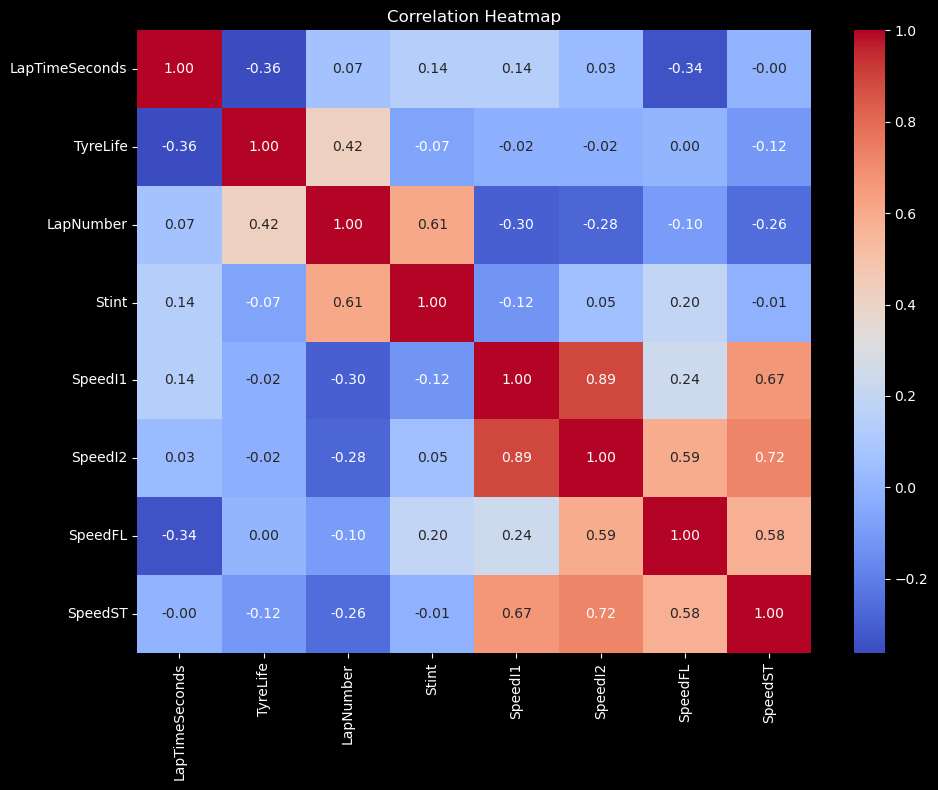

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = ['LapTimeSeconds', 'TyreLife', 'LapNumber', 'Stint', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']
corr_matrix = clean_laps[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()